# Import and load data

In [1]:
import pandas as pd
dataset = pd.read_csv('IndianFinancialNews.csv', index_col='Unnamed: 0')
dataset


,Date,Title,Description
0,"May 26, 2020, Tuesday","ATMs to become virtual bank branches, accept d...","Close to 14.6 per cent (or 35,000) of the 240,..."
1,"May 26, 2020, Tuesday",IDFC First Bank seniors to forgo 65% of bonus ...,"V Vaidyanathan, managing director and chief ex..."
2,"May 25, 2020, Monday","Huge scam in YES Bank for many years, says Enf...",Rana Kapoor's wife also charged with abetting ...
3,"May 24, 2020, Sunday","Bank of Maharashtra sanctioned Rs 2,789 cr in ...",The bank said it was now gearing up to extend ...
4,"May 23, 2020, Saturday",DCB Bank's profit before tax declines 37.6% to...,Net profit for the financial year ended March ...
...,...,...,...
49995,"February 11, 2003, Tuesday",Lic Mops Up Government Securities As Prices Crash,Lic Mops Up Government Securities As Prices Crash
49996,"February 11, 2003, Tuesday",Banks Plan To Raise Lending Rates Without Alte...,Banks Plan To Raise Lending Rates Without Alte...
49997,"February 10, 2003, Monday","Net Scheduled Inflows Of Rs 1,559.9 Crore","Net Scheduled Inflows Of Rs 1,559.9 Crore"
49998,"February 10, 2003, Monday",Rbi Calls Meet To Push Floating Rate Deposits,Rbi Calls Meet To Push Floating Rate Deposits


In [2]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         50000 non-null  object
 1   Title        50000 non-null  object
 2   Description  49290 non-null  object
dtypes: object(3)
memory usage: 1.5+ MB


# Data Preprocessing

In [3]:
# Basic text preprocessing

def clean_text(text):
    import re  # Regular expressions
    from nltk.stem import WordNetLemmatizer
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords

    stop_words = set(stopwords.words("english"))
   
    # Convert to lowercase
    text = text.lower()
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Lemmatize and remove stop words
    lemmatizer = WordNetLemmatizer()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    cleaned_text = " ".join(tokens)

    return cleaned_text

dataset['Description'] = dataset['Description'].astype(str)

dataset['Cleaned_Desc'] = dataset['Description'].apply(clean_text)
dataset


,Date,Title,Description,Cleaned_Desc
0,"May 26, 2020, Tuesday","ATMs to become virtual bank branches, accept d...","Close to 14.6 per cent (or 35,000) of the 240,...",close per cent atm india newage recyclers even...
1,"May 26, 2020, Tuesday",IDFC First Bank seniors to forgo 65% of bonus ...,"V Vaidyanathan, managing director and chief ex...",vaidyanathan managing director chief executive...
2,"May 25, 2020, Monday","Huge scam in YES Bank for many years, says Enf...",Rana Kapoor's wife also charged with abetting ...,rana kapoors wife also charged abetting crime
3,"May 24, 2020, Sunday","Bank of Maharashtra sanctioned Rs 2,789 cr in ...",The bank said it was now gearing up to extend ...,bank said gearing extend stimulus package anno...
4,"May 23, 2020, Saturday",DCB Bank's profit before tax declines 37.6% to...,Net profit for the financial year ended March ...,net profit financial year ended march stood cr...
...,...,...,...,...
49995,"February 11, 2003, Tuesday",Lic Mops Up Government Securities As Prices Crash,Lic Mops Up Government Securities As Prices Crash,lic mop government security price crash
49996,"February 11, 2003, Tuesday",Banks Plan To Raise Lending Rates Without Alte...,Banks Plan To Raise Lending Rates Without Alte...,bank plan raise lending rate without altering ...
49997,"February 10, 2003, Monday","Net Scheduled Inflows Of Rs 1,559.9 Crore","Net Scheduled Inflows Of Rs 1,559.9 Crore",net scheduled inflow crore
49998,"February 10, 2003, Monday",Rbi Calls Meet To Push Floating Rate Deposits,Rbi Calls Meet To Push Floating Rate Deposits,rbi call meet push floating rate deposit


# Topic Modelling

In [4]:
# Coherence Score Comparison using sample

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation


MAX_DOCS = 10000   # reduce if system is slow

sample_df = dataset[['Cleaned_Desc']].dropna()
if len(sample_df) > MAX_DOCS:
    sample_df = sample_df.sample(MAX_DOCS, random_state=42)

texts = [doc.split() for doc in sample_df['Cleaned_Desc']]

dictionary = Dictionary(texts)

def coherence_score(model, vectorizer, topn=10):
    feature_names = vectorizer.get_feature_names_out()
    
    topics = []
    for topic in model.components_:
        top_words = [feature_names[i] for i in topic.argsort()[-topn:]]
        topics.append(top_words)

    cm = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()

# Model comparison loop

results = {}

for Vectorizer in [CountVectorizer, TfidfVectorizer]:
    
    vectorizer = Vectorizer(max_df=0.95, min_df=2)
    vect_data = vectorizer.fit_transform(sample_df['Cleaned_Desc'])

    for Model in [NMF, LatentDirichletAllocation]:

        if Model == NMF:
            model = Model(n_components=6, random_state=42, max_iter=200)
        else:
            model = Model(n_components=6, random_state=42)

        model.fit(vect_data)

        score = coherence_score(model, vectorizer)
        key = f"{Model.__name__} + {Vectorizer.__name__}"
        results[key] = score

# Print ranked results
print("\n--- Coherence Ranking ---")
for k, v in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{k}: {v:.4f}")



--- Coherence Ranking ---
NMF + TfidfVectorizer: 0.6764
NMF + CountVectorizer: 0.6236
LatentDirichletAllocation + TfidfVectorizer: 0.5089
LatentDirichletAllocation + CountVectorizer: 0.4879


In [5]:
# Final Model and Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

final_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2)
X_tfidf = final_vectorizer.fit_transform(dataset['Cleaned_Desc'])

final_nmf = NMF(n_components=6, random_state=10, max_iter=300)
final_nmf.fit(X_tfidf)

for index,topic in enumerate(final_nmf.components_):
        results=([final_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
        print(results)


['said', 'sbi', 'largest', 'private', 'country', 'state', 'public', 'lender', 'sector', 'bank']
['group', 'international', 'united', 'sell', 'american', 'agreed', 'aig', 'bailout', 'repaying', 'nan']
['increase', 'posted', 'reported', 'ended', 'quarter', 'cent', 'per', 'crore', 'profit', 'net']
['general', 'lic', 'authority', 'irda', 'corporation', 'development', 'regulatory', 'company', 'life', 'insurance']
['cent', 'lending', 'cut', 'loan', 'per', 'point', 'basis', 'deposit', 'interest', 'rate']
['exchange', 'billion', 'today', 'governor', 'foreign', 'said', 'bank', 'rbi', 'india', 'reserve']


# Topic Clustering using KMeans

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=10, n_init=10)
cluster_labels = kmeans.fit_predict(X_tfidf)

dataset['Topic_Cluster'] = cluster_labels

terms = final_vectorizer.get_feature_names_out()

for i in range(6):
    center = kmeans.cluster_centers_[i]
    top_idx = center.argsort()[-10:]
    print(f"\nCluster {i}:")
    print([terms[j] for j in top_idx])



Cluster 0:
['development', 'authority', 'lic', 'general', 'irda', 'regulatory', 'corporation', 'company', 'life', 'insurance']

Cluster 1:
['loan', 'cut', 'point', 'basis', 'deposit', 'bank', 'interest', 'cent', 'per', 'rate']

Cluster 2:
['private', 'country', 'sbi', 'largest', 'india', 'state', 'lender', 'public', 'sector', 'bank']

Cluster 3:
['posted', 'bank', 'per', 'cent', 'reported', 'ended', 'quarter', 'crore', 'profit', 'net']

Cluster 4:
['india', 'said', 'finance', 'loan', 'financial', 'year', 'market', 'crore', 'nan', 'bank']

Cluster 5:
['exchange', 'billion', 'foreign', 'said', 'governor', 'today', 'rbi', 'bank', 'india', 'reserve']


| Cluster | Top Keywords (signal)                        | What it really means                | One-word Label |
| ------- | -------------------------------------------- | ----------------------------------- | -------------- |
| **0**   | lic, irda, regulatory, life, insurance       | Insurance + regulators + compliance | **Insurance**  |
| **1**   | loan, interest, rate, basis, cut, deposit    | Monetary & lending rate changes     | **Rates**      |
| **2**   | sbi, state, public, private, sector, largest | Bank identity & ownership           | **Banks**      |
| **3**   | profit, quarter, net, reported, crore        | Financial results & earnings        | **Earnings**   |
| **4**   | market, finance, year, loan, bank            | General finance / market movement   | **Markets**    |
| **5**   | rbi, reserve, governor, foreign, exchange    | Central bank + FX + policy          | **Policy**     |


In [7]:
topic_map = {
    0: "Insurance",
    1: "Rates",
    2: "Banks",
    3: "Earnings",
    4: "Markets",
    5: "Policy"
}

dataset['Topic_Label'] = dataset['Topic_Cluster'].map(topic_map)


# Impact Classification

In [8]:
impact_words = [
    "fraud", "scam", "probe", "investigat", "embezzle",
    "default", "npas?", "loan", "bailout", "bankrupt", "insolv",
    "crash", "slump", "selloff", "volatility",
    "merger", "acquisit", "takeover",
    "layoff", "retrench", "shutdown", "closure",
    "penalty", "fine", "sanction", "audit",
    "ban", "restriction", "regulatory",
    "policy", "inflation", "rate", "budget"
]



In [9]:
import re

def impact_label(text, topic):
    text = text.lower()

    hit = any(re.search(w, text) for w in impact_words)

    very_sensitive = ["policy", "rates"]
    sensitive = ["markets", "earnings"]

    if topic in very_sensitive:
        return "High Impact"

    if hit and topic in sensitive:
        return "High Impact"

    if hit:
        return "High Impact"

    return "Routine"


In [10]:
dataset['Impact_name'] = dataset.apply(lambda row: impact_label(row['Cleaned_Desc'], row['Topic_Label']), axis=1)
dataset


,Date,Title,Description,Cleaned_Desc,Topic_Cluster,Topic_Label,Impact_name
0,"May 26, 2020, Tuesday","ATMs to become virtual bank branches, accept d...","Close to 14.6 per cent (or 35,000) of the 240,...",close per cent atm india newage recyclers even...,1,Rates,Routine
1,"May 26, 2020, Tuesday",IDFC First Bank seniors to forgo 65% of bonus ...,"V Vaidyanathan, managing director and chief ex...",vaidyanathan managing director chief executive...,1,Rates,Routine
2,"May 25, 2020, Monday","Huge scam in YES Bank for many years, says Enf...",Rana Kapoor's wife also charged with abetting ...,rana kapoors wife also charged abetting crime,4,Markets,Routine
3,"May 24, 2020, Sunday","Bank of Maharashtra sanctioned Rs 2,789 cr in ...",The bank said it was now gearing up to extend ...,bank said gearing extend stimulus package anno...,4,Markets,High Impact
4,"May 23, 2020, Saturday",DCB Bank's profit before tax declines 37.6% to...,Net profit for the financial year ended March ...,net profit financial year ended march stood cr...,3,Earnings,Routine
...,...,...,...,...,...,...,...
49995,"February 11, 2003, Tuesday",Lic Mops Up Government Securities As Prices Crash,Lic Mops Up Government Securities As Prices Crash,lic mop government security price crash,4,Markets,High Impact
49996,"February 11, 2003, Tuesday",Banks Plan To Raise Lending Rates Without Alte...,Banks Plan To Raise Lending Rates Without Alte...,bank plan raise lending rate without altering ...,1,Rates,High Impact
49997,"February 10, 2003, Monday","Net Scheduled Inflows Of Rs 1,559.9 Crore","Net Scheduled Inflows Of Rs 1,559.9 Crore",net scheduled inflow crore,3,Earnings,Routine
49998,"February 10, 2003, Monday",Rbi Calls Meet To Push Floating Rate Deposits,Rbi Calls Meet To Push Floating Rate Deposits,rbi call meet push floating rate deposit,1,Rates,High Impact


In [11]:
impact_map = {
    "Routine":0,
    "High Impact":1
}

dataset['Impact_label'] = dataset['Impact_name'].map(impact_map)
dataset


,Date,Title,Description,Cleaned_Desc,Topic_Cluster,Topic_Label,Impact_name,Impact_label
0,"May 26, 2020, Tuesday","ATMs to become virtual bank branches, accept d...","Close to 14.6 per cent (or 35,000) of the 240,...",close per cent atm india newage recyclers even...,1,Rates,Routine,0
1,"May 26, 2020, Tuesday",IDFC First Bank seniors to forgo 65% of bonus ...,"V Vaidyanathan, managing director and chief ex...",vaidyanathan managing director chief executive...,1,Rates,Routine,0
2,"May 25, 2020, Monday","Huge scam in YES Bank for many years, says Enf...",Rana Kapoor's wife also charged with abetting ...,rana kapoors wife also charged abetting crime,4,Markets,Routine,0
3,"May 24, 2020, Sunday","Bank of Maharashtra sanctioned Rs 2,789 cr in ...",The bank said it was now gearing up to extend ...,bank said gearing extend stimulus package anno...,4,Markets,High Impact,1
4,"May 23, 2020, Saturday",DCB Bank's profit before tax declines 37.6% to...,Net profit for the financial year ended March ...,net profit financial year ended march stood cr...,3,Earnings,Routine,0
...,...,...,...,...,...,...,...,...
49995,"February 11, 2003, Tuesday",Lic Mops Up Government Securities As Prices Crash,Lic Mops Up Government Securities As Prices Crash,lic mop government security price crash,4,Markets,High Impact,1
49996,"February 11, 2003, Tuesday",Banks Plan To Raise Lending Rates Without Alte...,Banks Plan To Raise Lending Rates Without Alte...,bank plan raise lending rate without altering ...,1,Rates,High Impact,1
49997,"February 10, 2003, Monday","Net Scheduled Inflows Of Rs 1,559.9 Crore","Net Scheduled Inflows Of Rs 1,559.9 Crore",net scheduled inflow crore,3,Earnings,Routine,0
49998,"February 10, 2003, Monday",Rbi Calls Meet To Push Floating Rate Deposits,Rbi Calls Meet To Push Floating Rate Deposits,rbi call meet push floating rate deposit,1,Rates,High Impact,1


# Split to Train and Test data

In [12]:
from sklearn.model_selection import train_test_split

X = dataset['Cleaned_Desc']  # Text features
y = dataset['Impact_label']  # Now 'Impact_label' exists in our DataFrame

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


# Model Training

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Perceptron, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import NearestCentroid
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize


In [14]:

def get_model(model_name):
    models = {
        'LogisticRegression': LogisticRegression(),
        'LinearSVC': LinearSVC(),
        'RidgeClassifier': RidgeClassifier(),
        'Perceptron': Perceptron(),
        'NearestCentroid': NearestCentroid(),
        'SGDClassifier': SGDClassifier(),
        'MultinomialNB': MultinomialNB(),
        'BernoulliNB': BernoulliNB()
    }
    return models[model_name]


# Parameter grids


In [15]:
models_with_param_grids = {
    'LogisticRegression': [
        {'C': [0.1, 1], 'max_iter': [3000]}
    ],

    'LinearSVC': [
        {'C': [0.1, 1]}
    ],

    'RidgeClassifier': [
        {'alpha': [1.0, 10.0]}
    ],

    'Perceptron': [
        {'alpha': [1e-4, 1e-3], 'max_iter': [2000]}
    ],

    'MultinomialNB': [
        {'alpha': [0.1, 1.0]}
    ],

    'BernoulliNB': [
        {'alpha': [0.1, 1.0]}
    ],

    'SGDClassifier': [
        {'alpha': [1e-4, 1e-3], 'loss': ['log_loss'], 'max_iter': [2000]}
    ]
}


# Classification function


In [16]:

def run_classification_model(X_train_vec, y_train, X_test_vec, y_test, model_name, param_grid, grid_cv):
    model = get_model(model_name)
    grid = GridSearchCV(model, param_grid, scoring='f1_weighted', cv=grid_cv, n_jobs=-1, refit=True, error_score='raise')
    grid.fit(X_train_vec, y_train)
    y_pred = grid.predict(X_test_vec)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    # ROC AUC
    if len(set(y_test)) > 2:
        if hasattr(grid.best_estimator_, "predict_proba"):
            roc_auc = roc_auc_score(y_test, grid.predict_proba(X_test_vec), multi_class='ovr')
        else:
            scores = grid.decision_function(X_test_vec)
            roc_auc = roc_auc_score(label_binarize(y_test, classes=np.unique(y_test)), scores, multi_class='ovr')
    else:
        if hasattr(grid.best_estimator_, "predict_proba"):
            roc_auc = roc_auc_score(y_test, grid.predict_proba(X_test_vec)[:,1])
        else:
            scores = grid.decision_function(X_test_vec)
            roc_auc = roc_auc_score(y_test, scores)

    # Output Results
    print('.' * 25)
    print(f"{model_name} \nBest Parameters: {grid.best_params_}")
    print(f"F1 Score (weighted):{f1:.4f} \nROC AUC Score:{roc_auc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", cr)
    
    
    return grid, f1, roc_auc


In [17]:
full_db = pd.DataFrame()
i=0
results = {}

for model_name, param_grid in models_with_param_grids.items():
    grid, f1, roc_auc = run_classification_model(
        X_train_tfidf, y_train,
        X_test_tfidf, y_test,
        model_name, param_grid, grid_cv=5
    )
    i+=1
    results[i] = {
        'model_name': model_name,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'best_params': grid.best_params_,
        'model': grid
    }

sorted_df = (
    pd.DataFrame.from_dict(results, orient='index').sort_values(by=['roc_auc', 'f1_score'], ascending=False)
)

print('*'*50)
print(f"Top model: {sorted_df.iloc[0].model_name} | "
        f"F1={sorted_df.iloc[0]['f1_score']:.4f} | "
        f"ROC AUC={sorted_df.iloc[0]['roc_auc']:.4f}")
print('*'*50)

full_db = pd.concat([full_db, sorted_df])


.........................
LogisticRegression 
Best Parameters: {'C': 1, 'max_iter': 3000}
F1 Score (weighted):0.9711 
ROC AUC Score:0.9948
Confusion Matrix:
 [[3643    5]
 [ 286 6066]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96      3648
           1       1.00      0.95      0.98      6352

    accuracy                           0.97     10000
   macro avg       0.96      0.98      0.97     10000
weighted avg       0.97      0.97      0.97     10000

.........................
LinearSVC 
Best Parameters: {'C': 1}
F1 Score (weighted):0.9904 
ROC AUC Score:0.9976
Confusion Matrix:
 [[3648    0]
 [  96 6256]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      3648
           1       1.00      0.98      0.99      6352

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted a

In [18]:
full_db[['model_name','f1_score','roc_auc']]


,model_name,f1_score,roc_auc
2,LinearSVC,0.990426,0.997630
4,Perceptron,0.985021,0.996171
1,LogisticRegression,0.971110,0.994796
3,RidgeClassifier,0.961219,0.989870
7,SGDClassifier,0.958289,0.988683
6,BernoulliNB,0.934051,0.983811
5,MultinomialNB,0.816770,0.954173


# Test with sample

In [19]:
print(X_test[[12447]],'\n', y_test[12447])


12447    say bank would provide information matter cbi ...
Name: Cleaned_Desc, dtype: object 
 1


In [20]:
single_news = X_test[[12447]]  

model = full_db.iloc[0]['model']
single_vec = tfidf_vectorizer.transform(single_news)
prediction = model.predict(single_vec)

impact_map = {
    0:"Routine",
    1:"High Impact"
}

print(impact_map[prediction[0]])



High Impact


# Visualization

### Distribution of High Impact and Routine News

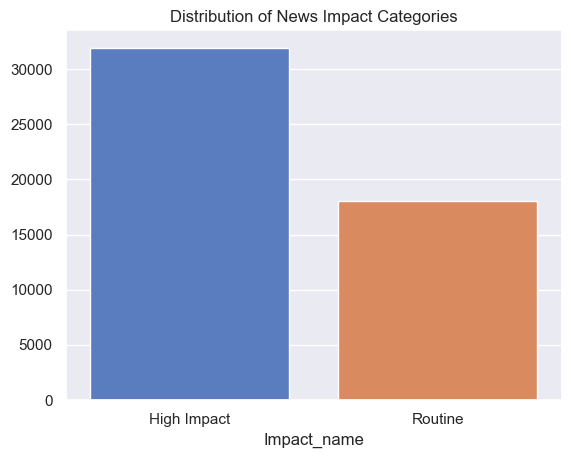

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme('notebook')

impact_name = dataset['Impact_name'].value_counts()
sns.barplot(x=impact_name.index, y=impact_name.values, hue=impact_name.index, palette='muted')
plt.title('Distribution of News Impact Categories')
plt.show()


### Topics distribution with most and least articles

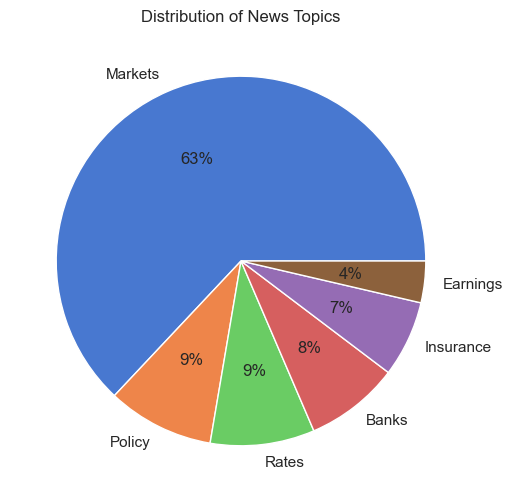

In [22]:
colors = sns.color_palette('muted')

topic_labels = dataset['Topic_Label'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(topic_labels, labels=topic_labels.index, colors=colors, autopct='%.0f%%')

plt.title('Distribution of News Topics')
plt.show()


### Topics distribution with News Impact

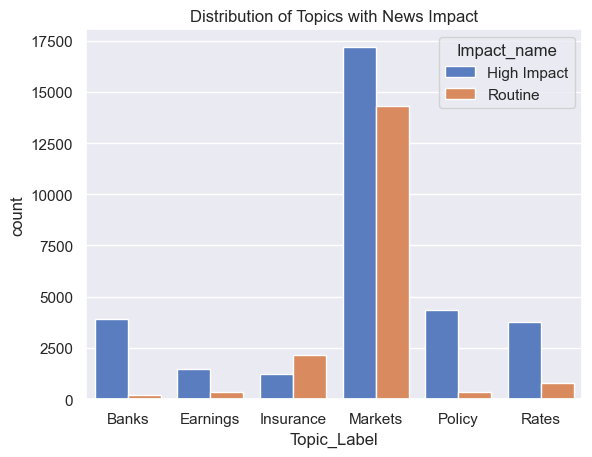

In [23]:
groupby_data = dataset.groupby('Topic_Label')['Impact_name'].value_counts().reset_index()

sns.barplot(x=groupby_data['Topic_Label'], y=groupby_data['count'], hue=groupby_data['Impact_name'], 
            palette='muted', legend=True, errorbar=None)
plt.title('Distribution of Topics with News Impact')
plt.show()


### Yearwise Topics trend

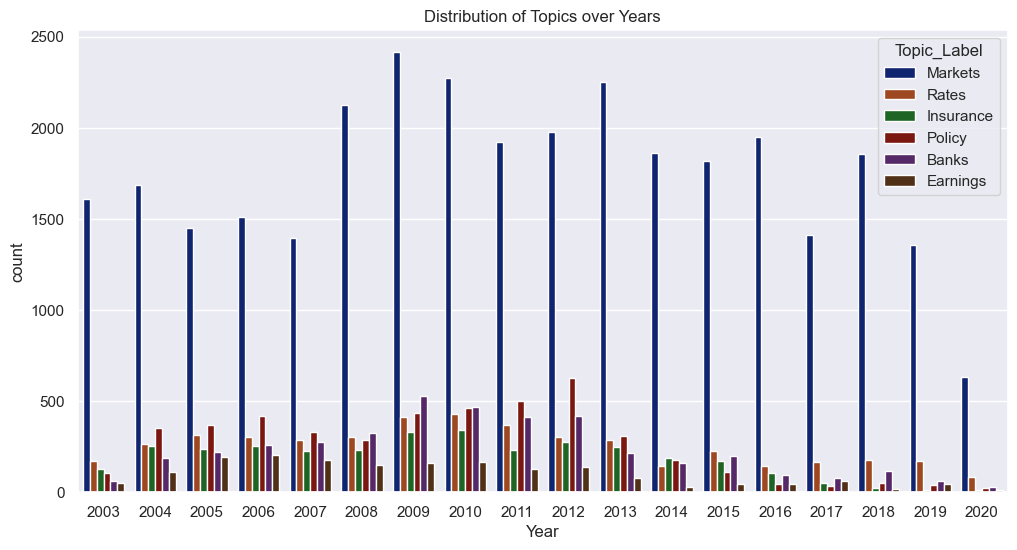

In [24]:
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')
dataset['Year'] = dataset['Date'].dt.year

groupby_data = dataset.groupby('Year')['Topic_Label'].value_counts().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x=groupby_data['Year'], y=groupby_data['count'], hue=groupby_data['Topic_Label'], 
            palette='dark', legend=True, errorbar=None)

plt.title('Distribution of Topics over Years')
plt.show()


### Yearwise News Impact trend

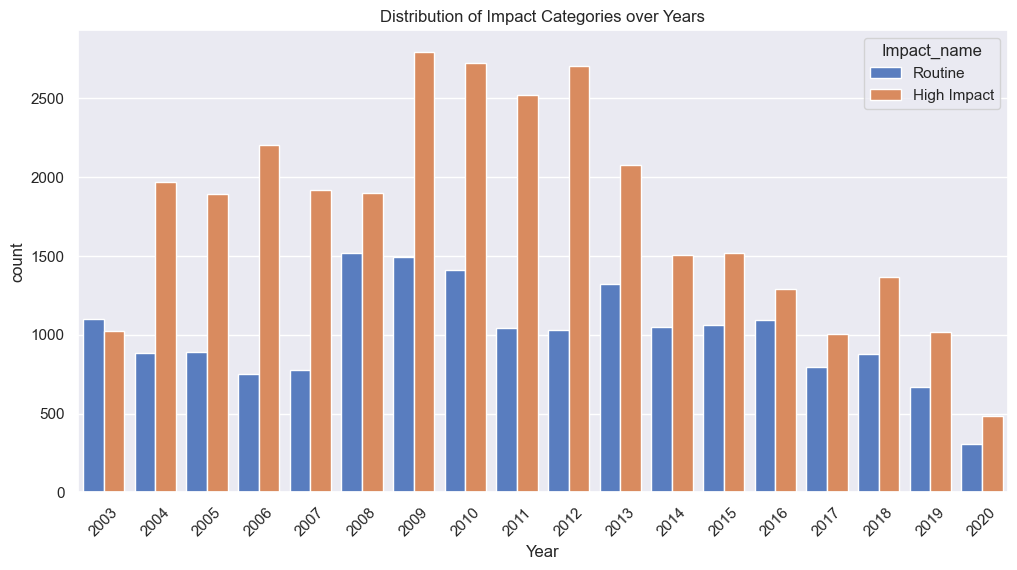

In [25]:
groupby_data = dataset.groupby('Year')['Impact_name'].value_counts().reset_index()

impact_name = groupby_data['Impact_name'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=groupby_data['Year'], y=groupby_data['count'], hue=groupby_data['Impact_name'], palette='muted')
plt.title('Distribution of Impact Categories over Years')
plt.xticks(rotation=45)
plt.show()


### Most Impactful Days of week

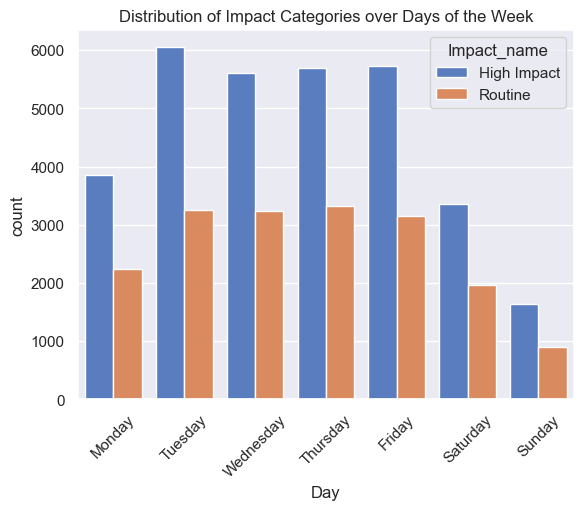

In [26]:
dataset['Day'] = dataset['Date'].dt.day_of_week
day_of_week_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}
groupby_data = dataset.groupby('Day')['Impact_name'].value_counts().reset_index()
groupby_data['Day'] = groupby_data['Day'].map(day_of_week_map)

sns.barplot(x=groupby_data['Day'], y=groupby_data['count'], hue=groupby_data['Impact_name'], palette='muted')
plt.title('Distribution of Impact Categories over Days of the Week')
plt.xticks(rotation=45)
plt.show()


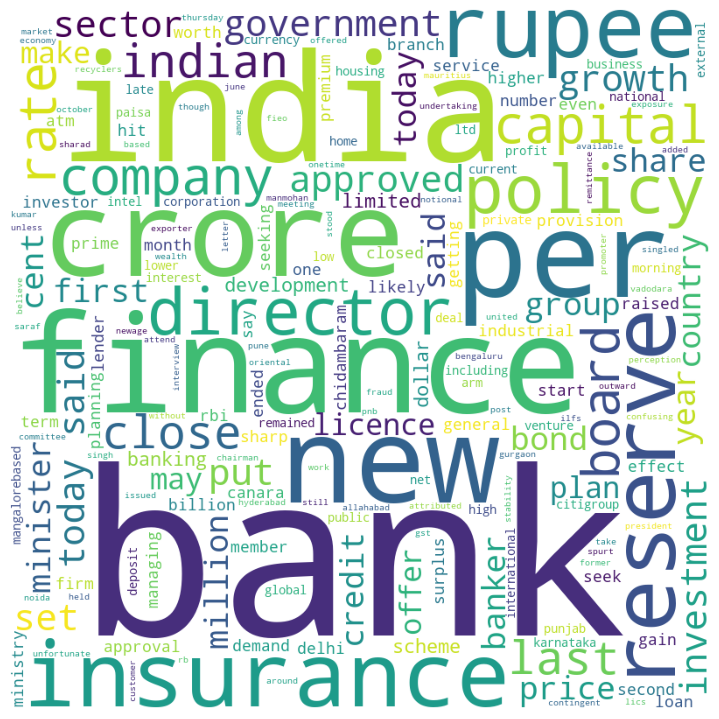

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

comment_words = []

dataset.index=range(dataset.shape[0])
for i in range(0, len(dataset), 750):
    comment_words.append(dataset['Cleaned_Desc'][i])
    vv=" ".join(comment_words)          
    wordcloud = WordCloud(width = 800, height = 800, 
                                background_color ='white', 
                                      min_font_size = 10).generate(vv)         
plt.figure(figsize = (9, 7), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() 

